In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivangiv1/pandamic-data/time_series_covid19_deaths_global.csv
/kaggle/input/datasets/shivangiv1/pandamic-data/time_series_covid19_recovered_global.csv
/kaggle/input/datasets/shivangiv1/pandamic-data/time_series_covid19_confirmed_global.csv


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression

# Load COVID-19 datasets
confirmed = pd.read_csv(
    '/kaggle/input/datasets/shivangiv1/pandamic-data/time_series_covid19_confirmed_global.csv'
)

deaths = pd.read_csv(
    '/kaggle/input/datasets/shivangiv1/pandamic-data/time_series_covid19_deaths_global.csv'
)

recovered = pd.read_csv(
    '/kaggle/input/datasets/shivangiv1/pandamic-data/time_series_covid19_recovered_global.csv'
)

print("Confirmed:", confirmed.shape)
print("Deaths:", deaths.shape)
print("Recovered:", recovered.shape)

Confirmed: (289, 1147)
Deaths: (289, 1147)
Recovered: (274, 1147)


In [8]:
id_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']

# Confirmed
confirmed_long = confirmed.melt(
    id_vars=id_cols,
    var_name='Date',
    value_name='Confirmed'
)

# Deaths
deaths_long = deaths.melt(
    id_vars=id_cols,
    var_name='Date',
    value_name='Deaths'
)

# Recovered
recovered_long = recovered.melt(
    id_vars=id_cols,
    var_name='Date',
    value_name='Recovered'
)

# Convert dates
confirmed_long['Date'] = pd.to_datetime(
    confirmed_long['Date'],
    format='%m/%d/%y'
)

deaths_long['Date'] = pd.to_datetime(
    deaths_long['Date'],
    format='%m/%d/%y'
)

recovered_long['Date'] = pd.to_datetime(
    recovered_long['Date'],
    format='%m/%d/%y'
)

print(confirmed_long.head())

  Province/State Country/Region       Lat       Long       Date  Confirmed
0            NaN    Afghanistan  33.93911  67.709953 2020-01-22          0
1            NaN        Albania  41.15330  20.168300 2020-01-22          0
2            NaN        Algeria  28.03390   1.659600 2020-01-22          0
3            NaN        Andorra  42.50630   1.521800 2020-01-22          0
4            NaN         Angola -11.20270  17.873900 2020-01-22          0


In [9]:
merged = confirmed_long.merge(
    deaths_long,
    on=['Province/State', 'Country/Region', 'Lat', 'Long', 'Date'],
    how='left'
)

merged = merged.merge(
    recovered_long,
    on=['Province/State', 'Country/Region', 'Lat', 'Long', 'Date'],
    how='left'
)

merged[['Confirmed', 'Deaths', 'Recovered']] = (
    merged[['Confirmed', 'Deaths', 'Recovered']]
    .fillna(0)
)

print(merged.head())
print(merged.shape)

  Province/State Country/Region       Lat       Long       Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953 2020-01-22          0   
1            NaN        Albania  41.15330  20.168300 2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600 2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800 2020-01-22          0   
4            NaN         Angola -11.20270  17.873900 2020-01-22          0   

   Deaths  Recovered  
0       0        0.0  
1       0        0.0  
2       0        0.0  
3       0        0.0  
4       0        0.0  
(330327, 8)


In [10]:
global_data = (
    merged
    .groupby('Date')[['Confirmed', 'Deaths', 'Recovered']]
    .sum()
    .reset_index()
)

# Daily new cases
global_data['New_Cases'] = (
    global_data['Confirmed']
    .diff()
    .fillna(0)
    .clip(lower=0)
)

# Daily new deaths
global_data['New_Deaths'] = (
    global_data['Deaths']
    .diff()
    .fillna(0)
    .clip(lower=0)
)

# Case Fatality Rate
global_data['CFR'] = np.where(
    global_data['Confirmed'] > 0,
    (global_data['Deaths'] / global_data['Confirmed']) * 100,
    np.nan
)

global_data.head()

,Date,Confirmed,Deaths,Recovered,New_Cases,New_Deaths,CFR
0,2020-01-22,557,17,30.0,0.0,0.0,3.052065
1,2020-01-23,657,18,32.0,100.0,1.0,2.739726
2,2020-01-24,944,26,39.0,287.0,8.0,2.754237
3,2020-01-25,1437,42,42.0,493.0,16.0,2.922756
4,2020-01-26,2120,56,56.0,683.0,14.0,2.641509


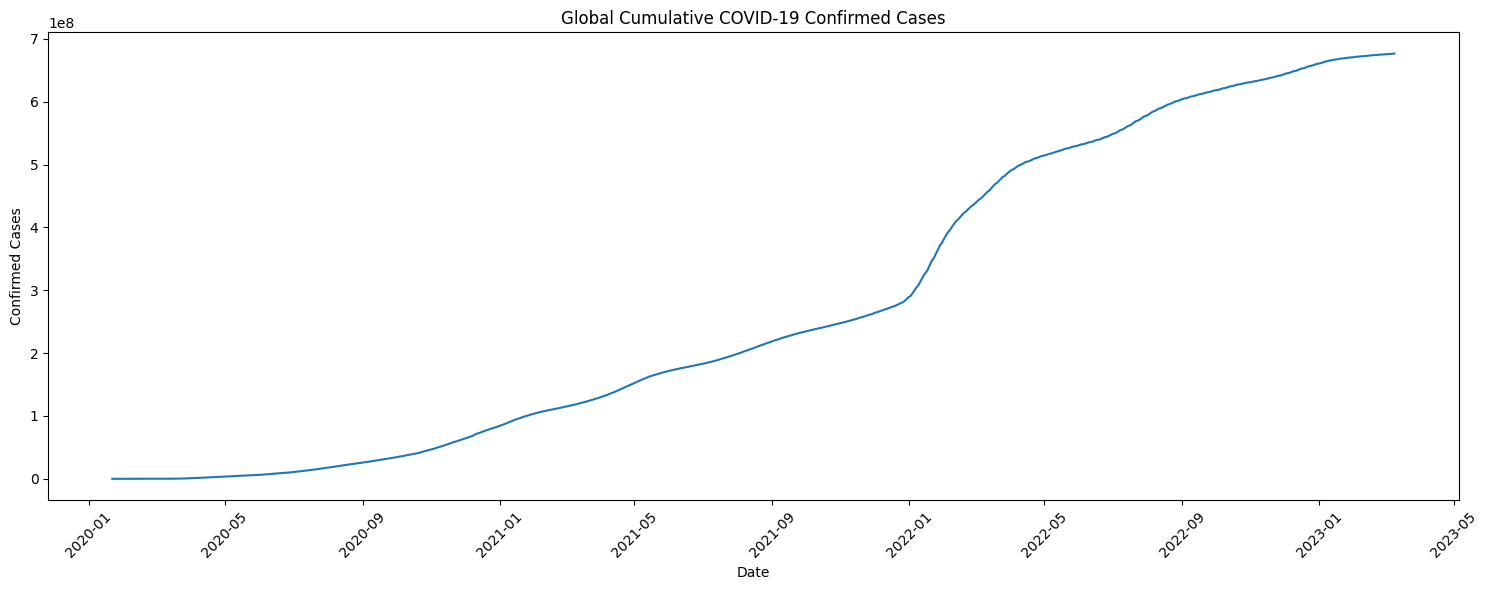

In [11]:
plt.figure(figsize=(15,6))

plt.plot(
    global_data['Date'],
    global_data['Confirmed']
)

plt.title('Global Cumulative COVID-19 Confirmed Cases')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

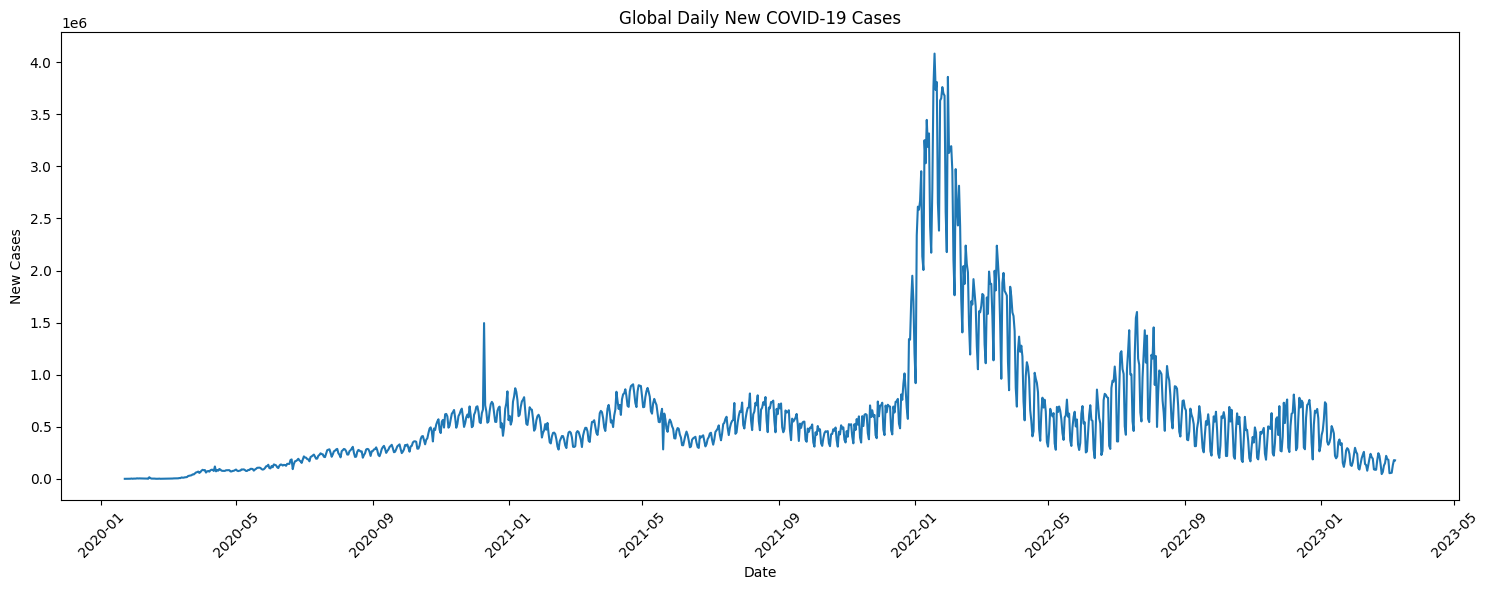

In [12]:
plt.figure(figsize=(15,6))

plt.plot(
    global_data['Date'],
    global_data['New_Cases']
)

plt.title('Global Daily New COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('New Cases')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

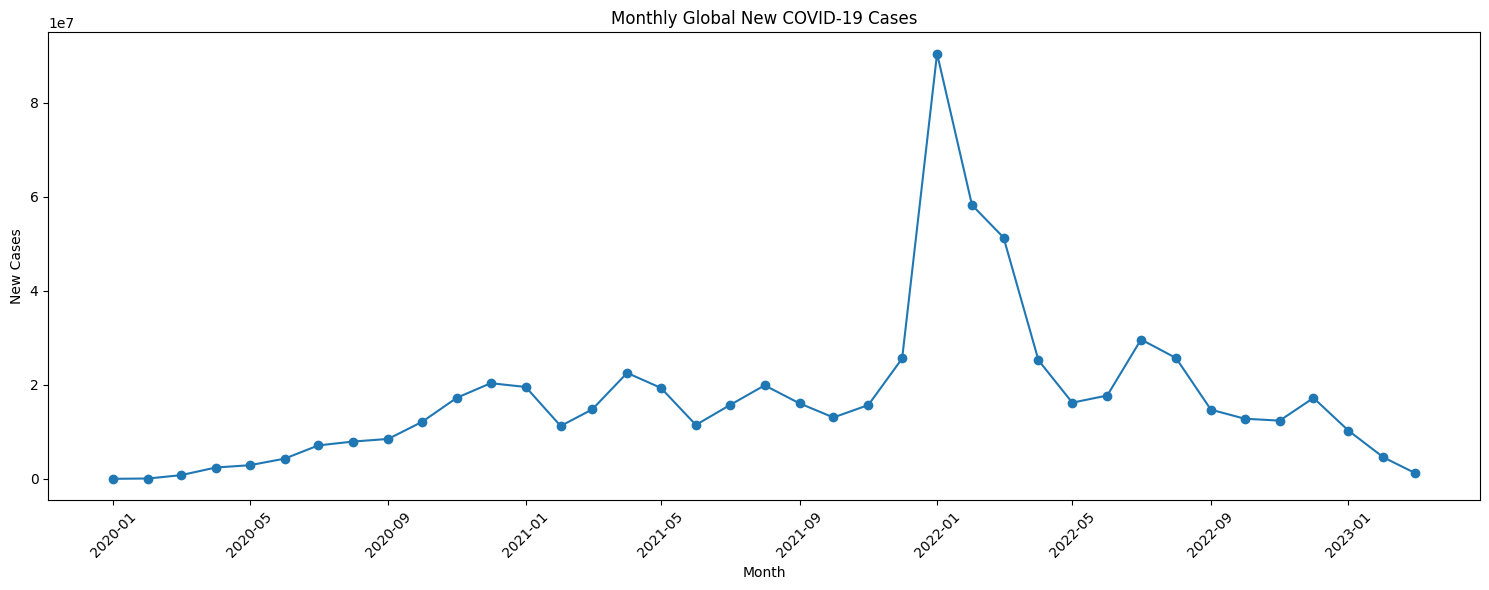

In [13]:
monthly = global_data.copy()

monthly['Month'] = (
    monthly['Date']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_cases = (
    monthly
    .groupby('Month')['New_Cases']
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_cases['Month'],
    monthly_cases['New_Cases'],
    marker='o'
)

plt.title('Monthly Global New COVID-19 Cases')
plt.xlabel('Month')
plt.ylabel('New Cases')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

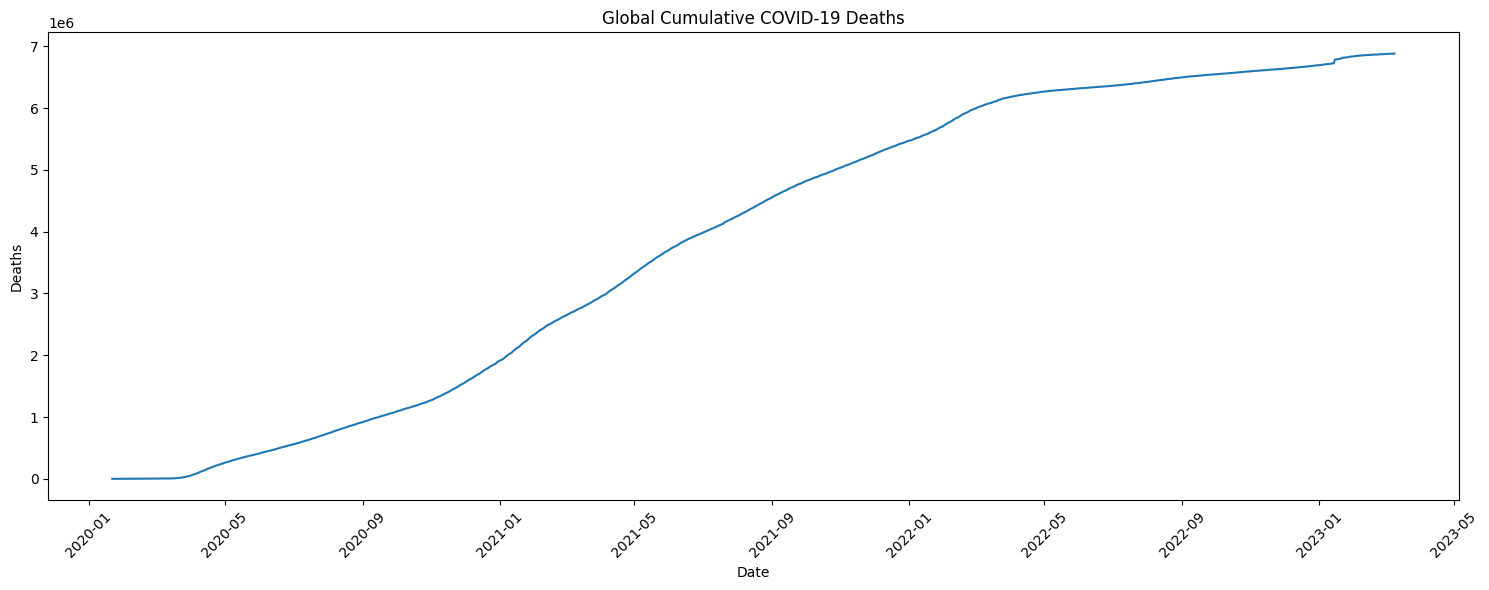

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    global_data['Date'],
    global_data['Deaths']
)

plt.title('Global Cumulative COVID-19 Deaths')
plt.xlabel('Date')
plt.ylabel('Deaths')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

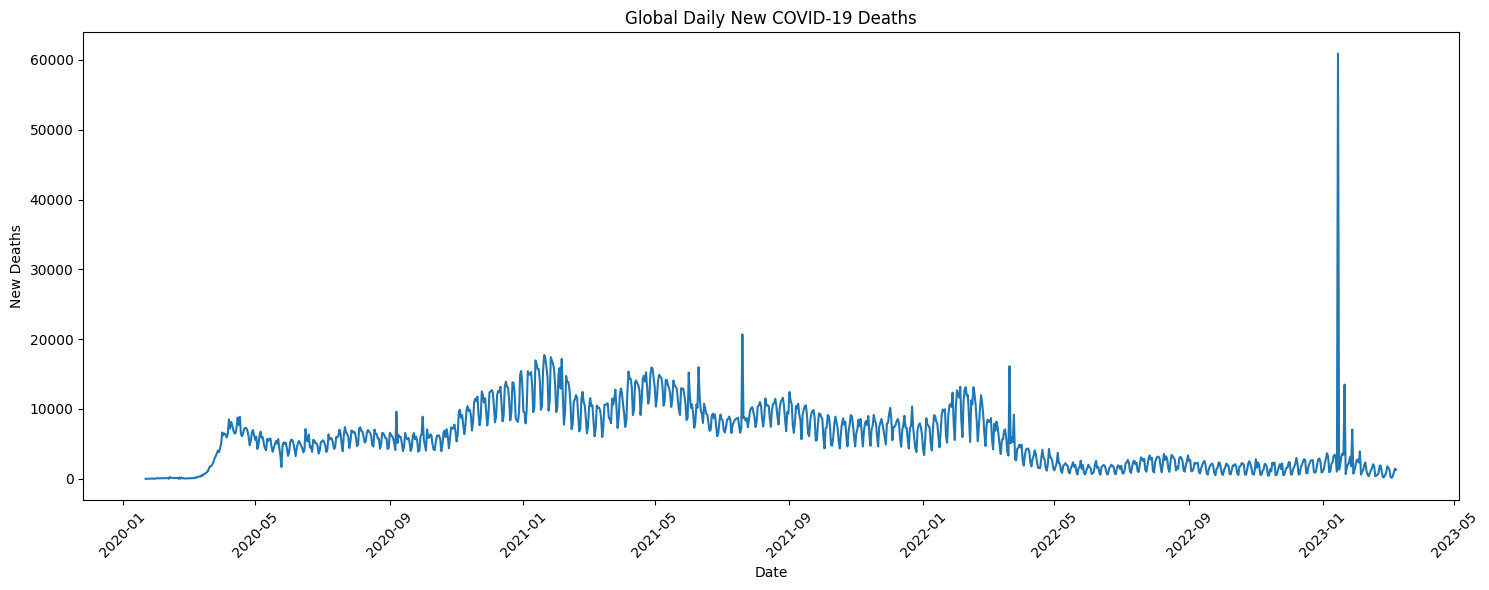

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    global_data['Date'],
    global_data['New_Deaths']
)

plt.title('Global Daily New COVID-19 Deaths')
plt.xlabel('Date')
plt.ylabel('New Deaths')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

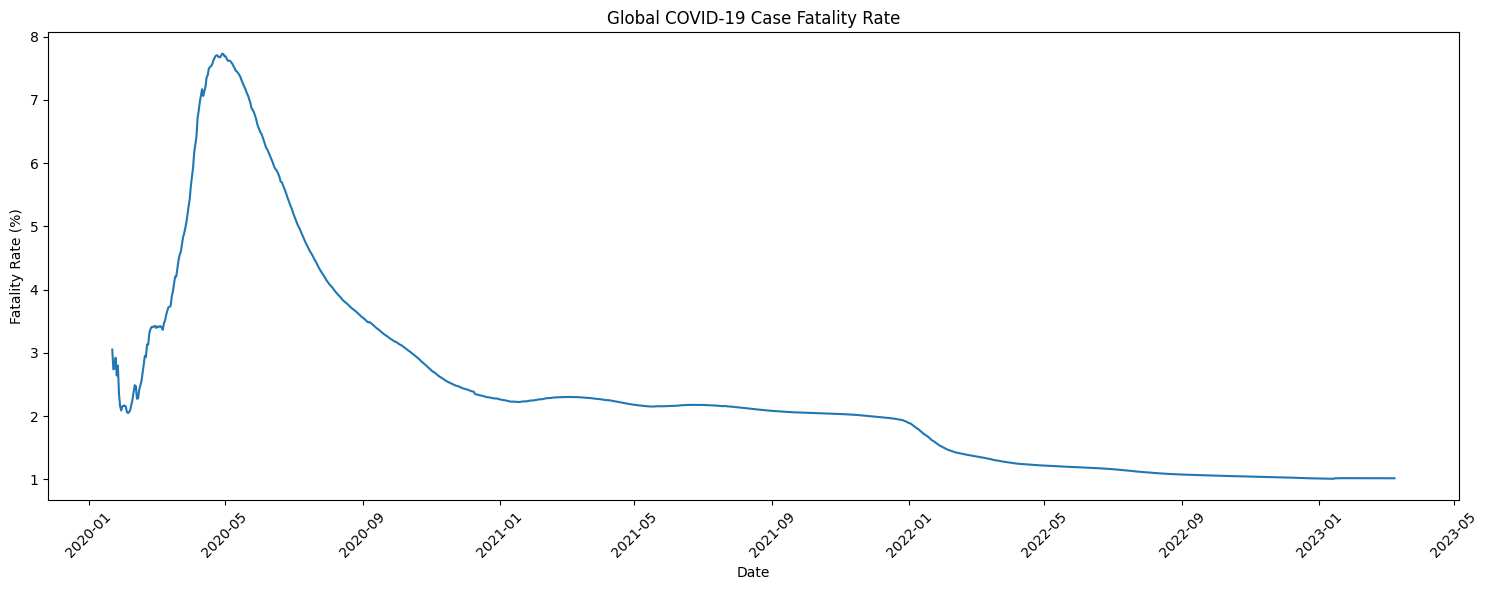

In [16]:
plt.figure(figsize=(15,6))

plt.plot(
    global_data['Date'],
    global_data['CFR']
)

plt.title('Global COVID-19 Case Fatality Rate')
plt.xlabel('Date')
plt.ylabel('Fatality Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
country_daily = (
    merged
    .groupby(['Country/Region', 'Date'])[
        ['Confirmed', 'Deaths']
    ]
    .sum()
    .reset_index()
)

country_daily['New_Cases'] = (
    country_daily
    .groupby('Country/Region')['Confirmed']
    .diff()
    .fillna(0)
    .clip(lower=0)
)

country_daily.head()

,Country/Region,Date,Confirmed,Deaths,New_Cases
0,Afghanistan,2020-01-22,0,0,0.0
1,Afghanistan,2020-01-23,0,0,0.0
2,Afghanistan,2020-01-24,0,0,0.0
3,Afghanistan,2020-01-25,0,0,0.0
4,Afghanistan,2020-01-26,0,0,0.0


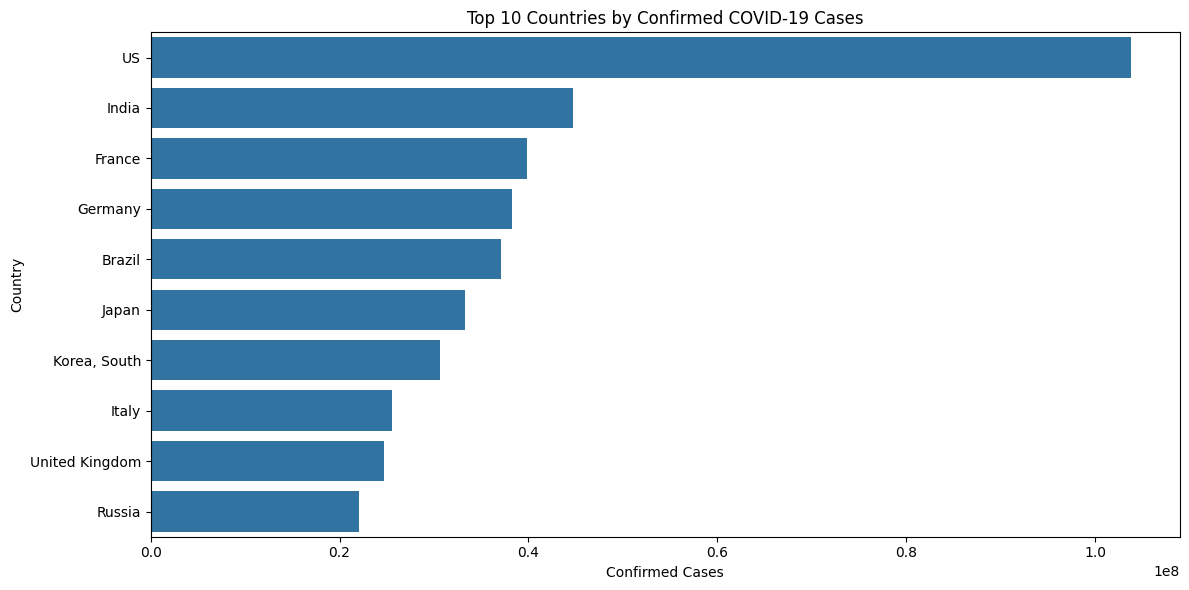

In [18]:
top_10 = (
    country_daily
    .groupby('Country/Region')['Confirmed']
    .max()
    .nlargest(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

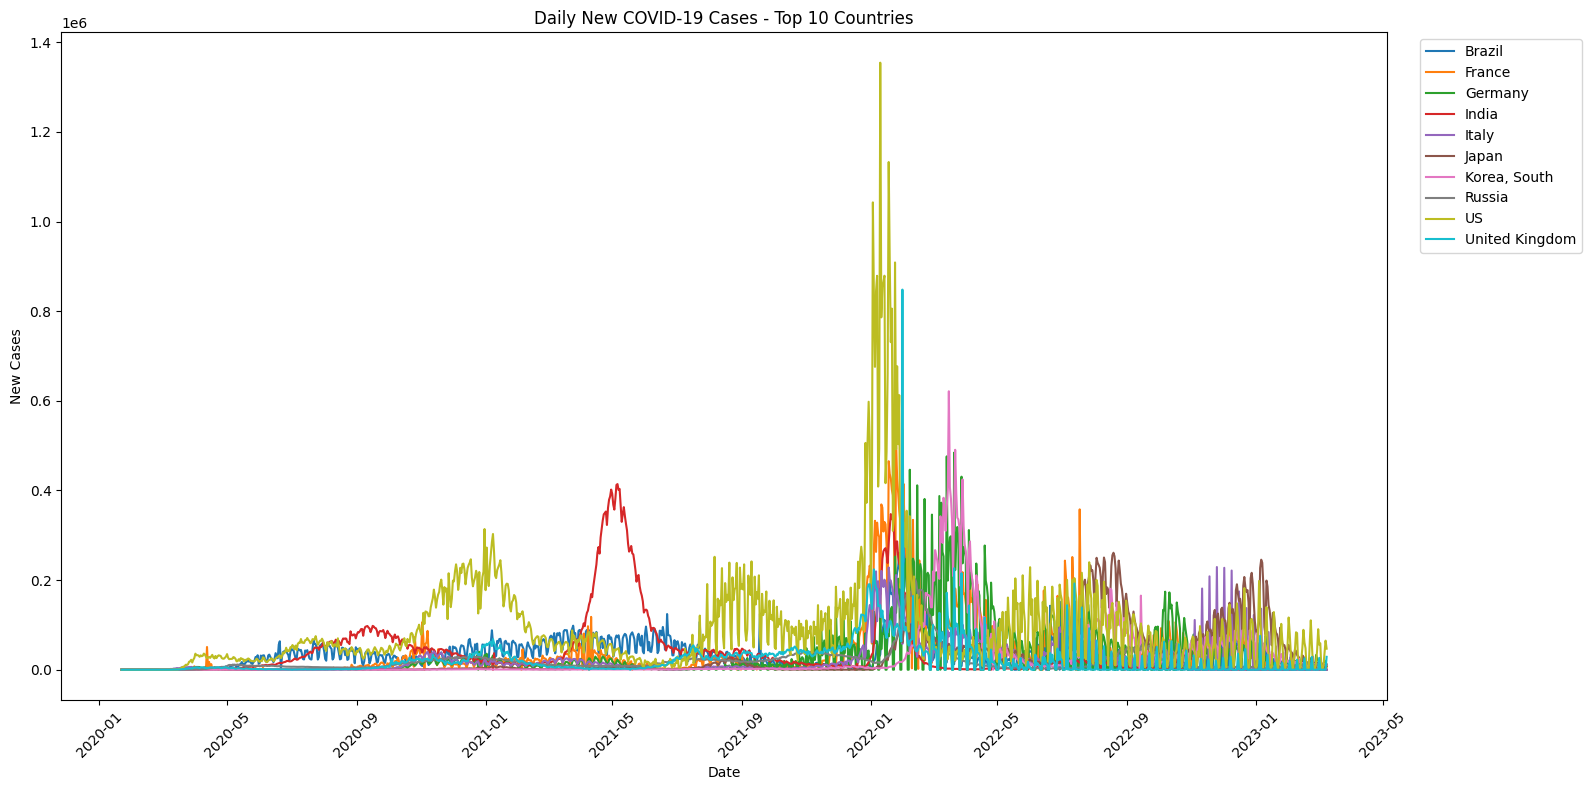

In [19]:
top_countries = top_10.index

top10_daily = country_daily[
    country_daily['Country/Region'].isin(top_countries)
]

plt.figure(figsize=(16,8))

sns.lineplot(
    data=top10_daily,
    x='Date',
    y='New_Cases',
    hue='Country/Region',
    errorbar=None
)

plt.title(
    'Daily New COVID-19 Cases - Top 10 Countries'
)

plt.xlabel('Date')
plt.ylabel('New Cases')

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [20]:
latest_date = merged['Date'].max()

latest_data = (
    merged[merged['Date'] == latest_date]
    .groupby(['Country/Region', 'Lat', 'Long'])[
        ['Confirmed', 'Deaths']
    ]
    .sum()
    .reset_index()
)

fig = px.scatter_geo(
    latest_data,
    lat='Lat',
    lon='Long',
    size='Confirmed',
    color='Deaths',
    hover_name='Country/Region',
    title='Global COVID-19 Geographic Spread'
)

fig.show()

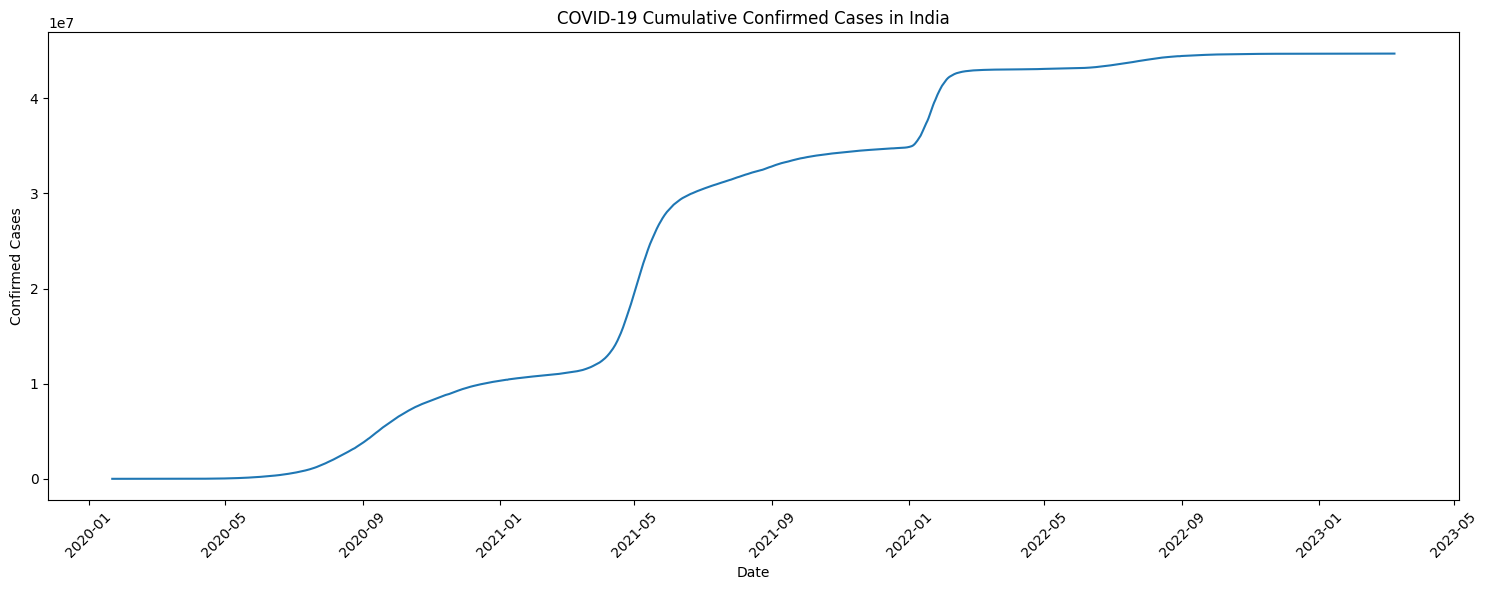

In [21]:
india = country_daily[
    country_daily['Country/Region'] == 'India'
].copy()

plt.figure(figsize=(15,6))

plt.plot(
    india['Date'],
    india['Confirmed']
)

plt.title('COVID-19 Cumulative Confirmed Cases in India')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

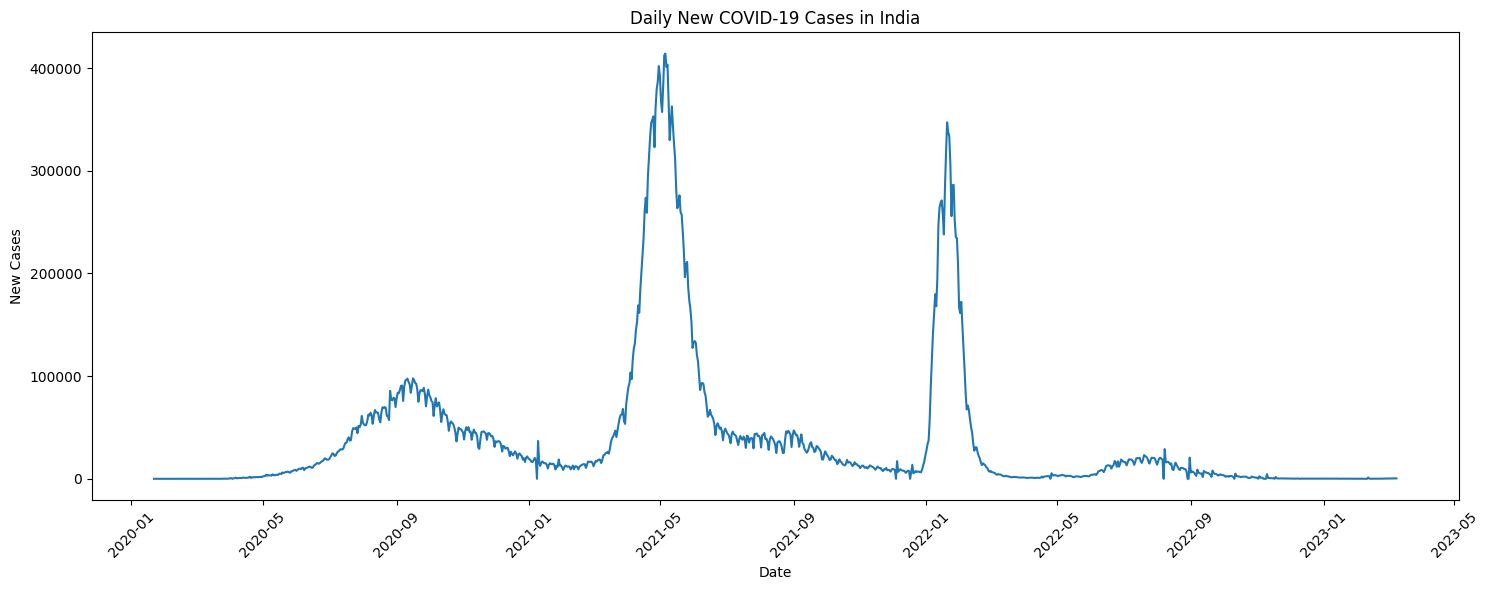

In [22]:
plt.figure(figsize=(15,6))

plt.plot(
    india['Date'],
    india['New_Cases']
)

plt.title('Daily New COVID-19 Cases in India')
plt.xlabel('Date')
plt.ylabel('New Cases')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

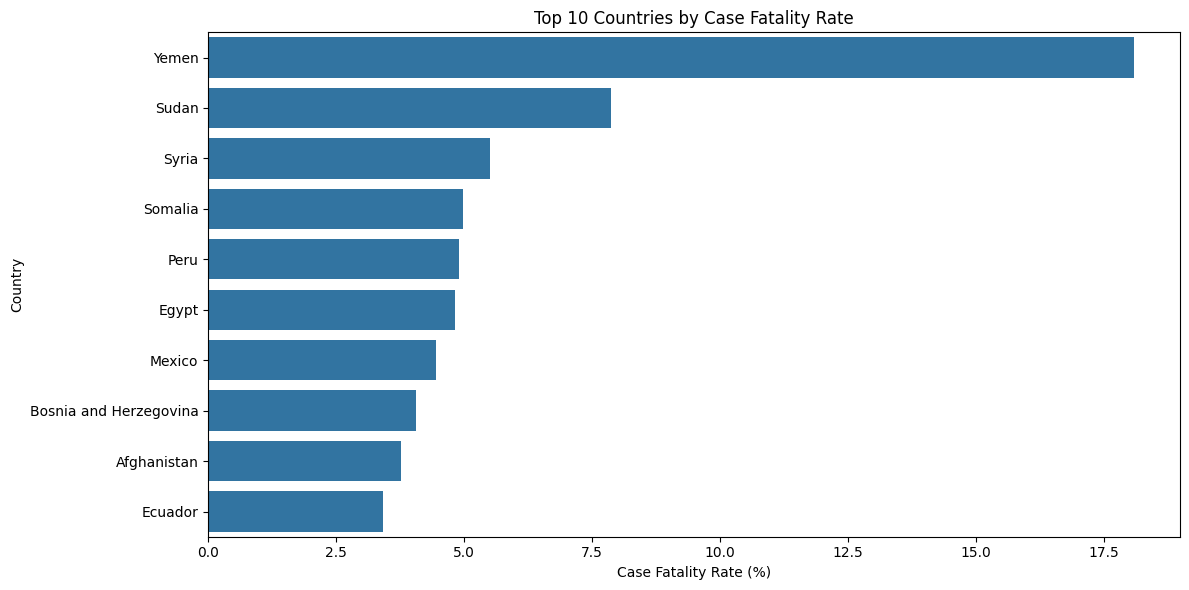

In [23]:
country_latest = (
    country_daily
    .sort_values('Date')
    .groupby('Country/Region')
    .tail(1)
    .copy()
)

country_latest['CFR'] = np.where(
    country_latest['Confirmed'] > 0,
    (country_latest['Deaths'] / country_latest['Confirmed']) * 100,
    np.nan
)

# Ignore countries with very small numbers of cases
cfr_data = country_latest[
    country_latest['Confirmed'] >= 10000
]

top_cfr = cfr_data.nlargest(10, 'CFR')

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cfr,
    x='CFR',
    y='Country/Region'
)

plt.title('Top 10 Countries by Case Fatality Rate')
plt.xlabel('Case Fatality Rate (%)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

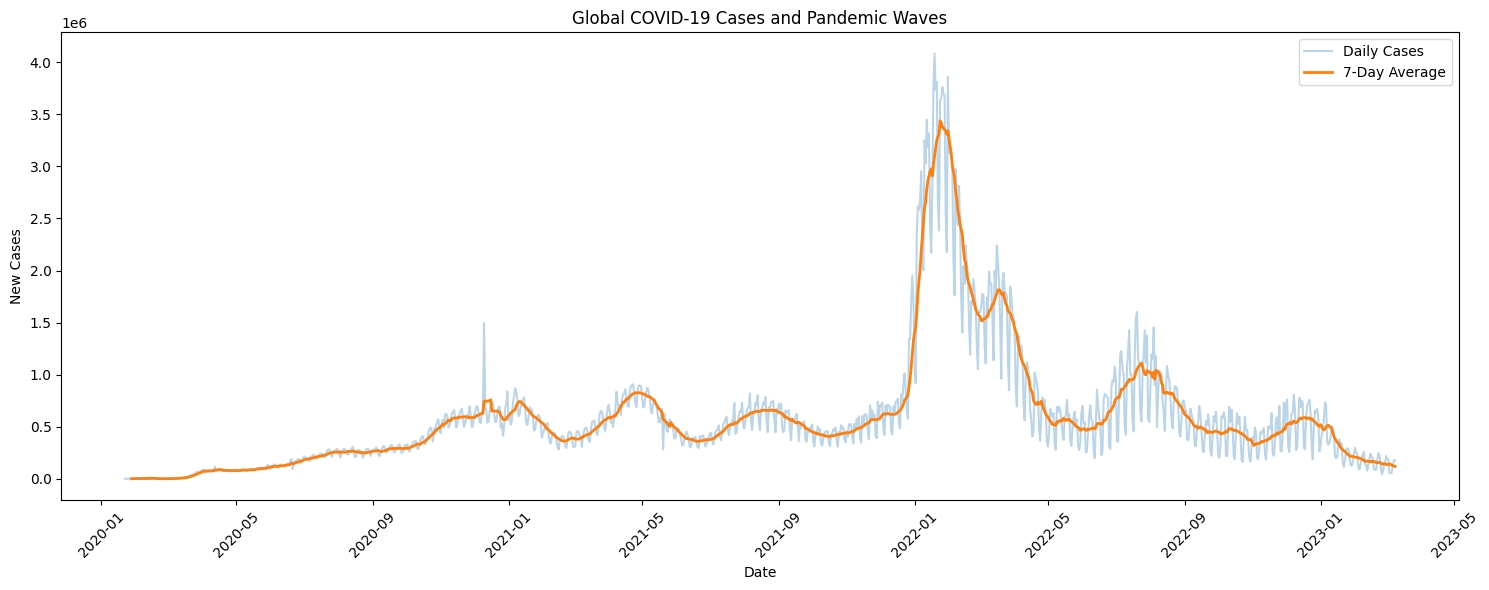

In [24]:
global_data['7_Day_Avg'] = (
    global_data['New_Cases']
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    global_data['Date'],
    global_data['New_Cases'],
    alpha=0.3,
    label='Daily Cases'
)

plt.plot(
    global_data['Date'],
    global_data['7_Day_Avg'],
    linewidth=2,
    label='7-Day Average'
)

plt.title('Global COVID-19 Cases and Pandemic Waves')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
peak_cases = global_data.loc[
    global_data['New_Cases'].idxmax()
]

print("Peak Date:", peak_cases['Date'].date())
print("Peak New Cases:", int(peak_cases['New_Cases']))

Peak Date: 2022-01-19
Peak New Cases: 4083281


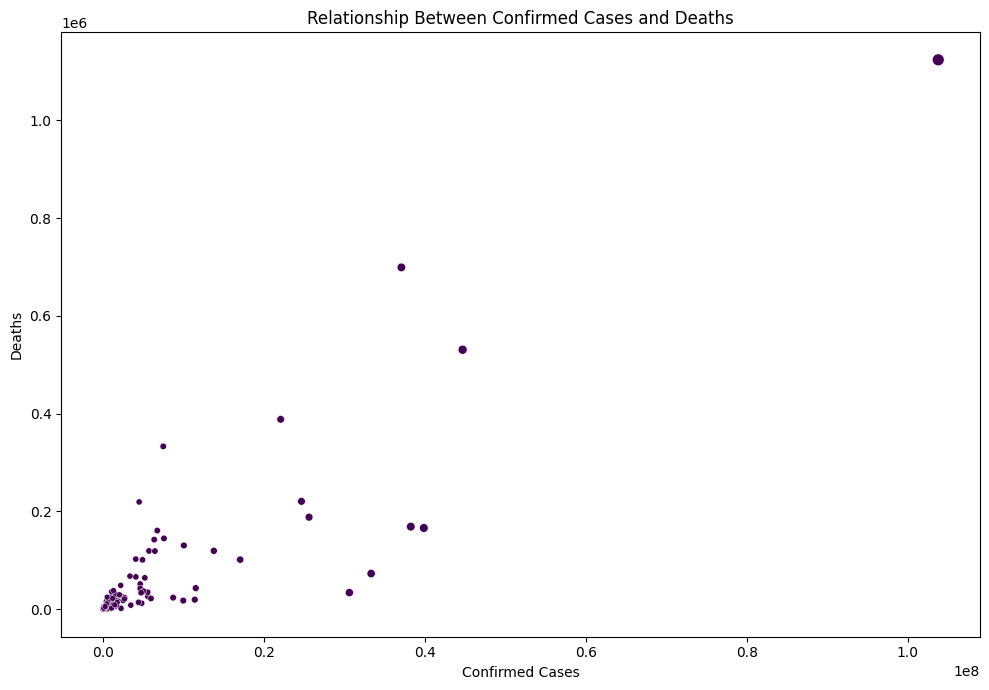

In [26]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=country_latest,
    x='Confirmed',
    y='Deaths',
    size='Confirmed',
    hue='CFR',
    palette='viridis',
    legend=False
)

plt.title('Relationship Between Confirmed Cases and Deaths')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')

plt.tight_layout()
plt.show()

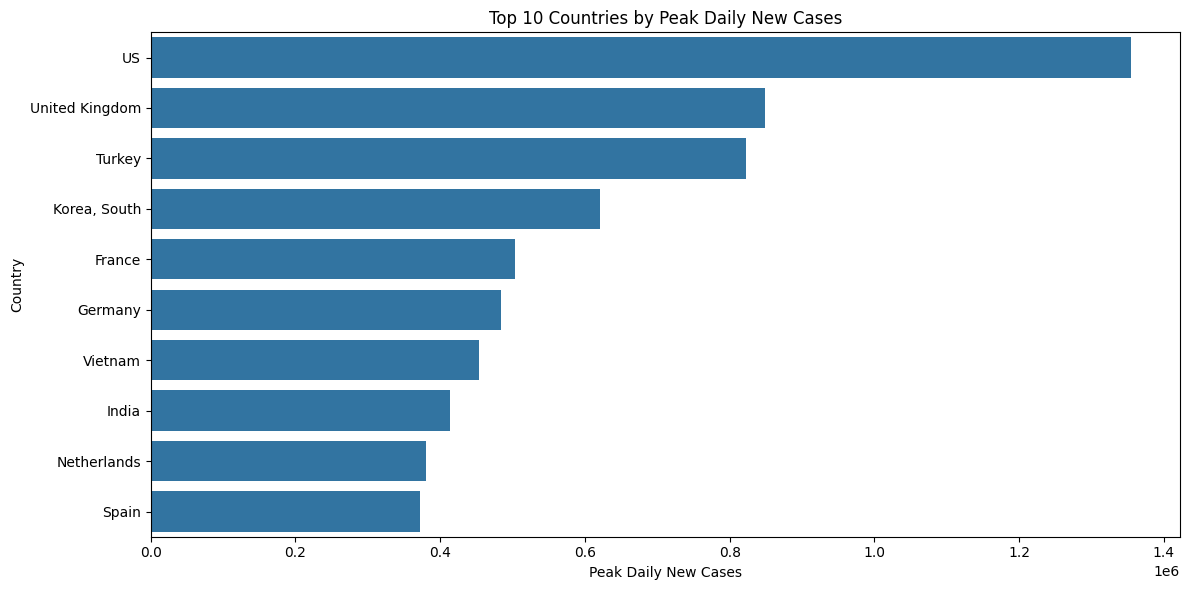

In [27]:
country_peak = (
    country_daily
    .groupby('Country/Region')['New_Cases']
    .max()
    .nlargest(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_peak.values,
    y=country_peak.index
)

plt.title('Top 10 Countries by Peak Daily New Cases')
plt.xlabel('Peak Daily New Cases')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

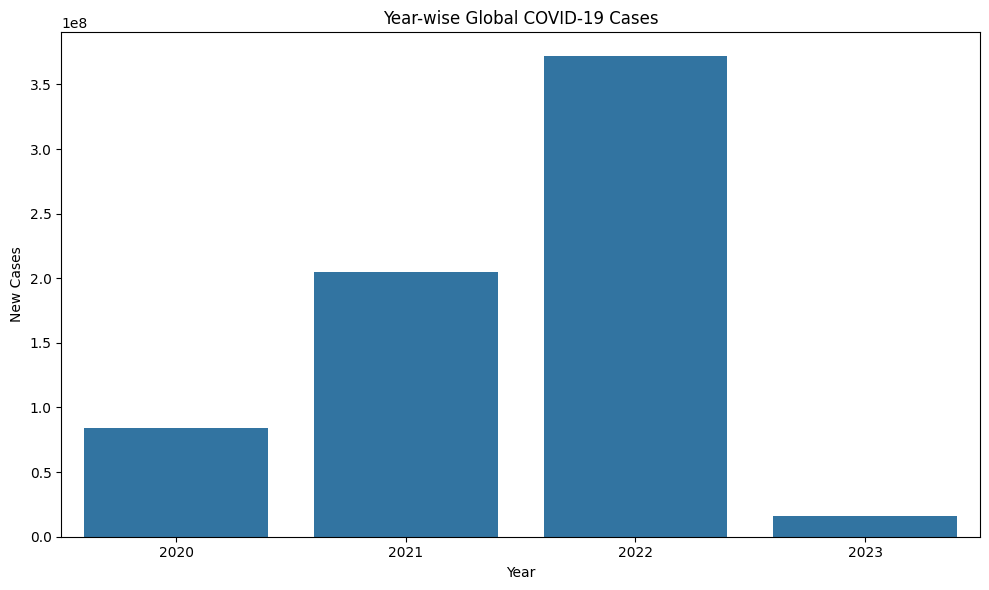

In [28]:
yearly_cases = (
    global_data
    .assign(Year=global_data['Date'].dt.year)
    .groupby('Year')['New_Cases']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=yearly_cases,
    x='Year',
    y='New_Cases'
)

plt.title('Year-wise Global COVID-19 Cases')
plt.xlabel('Year')
plt.ylabel('New Cases')

plt.tight_layout()
plt.show()

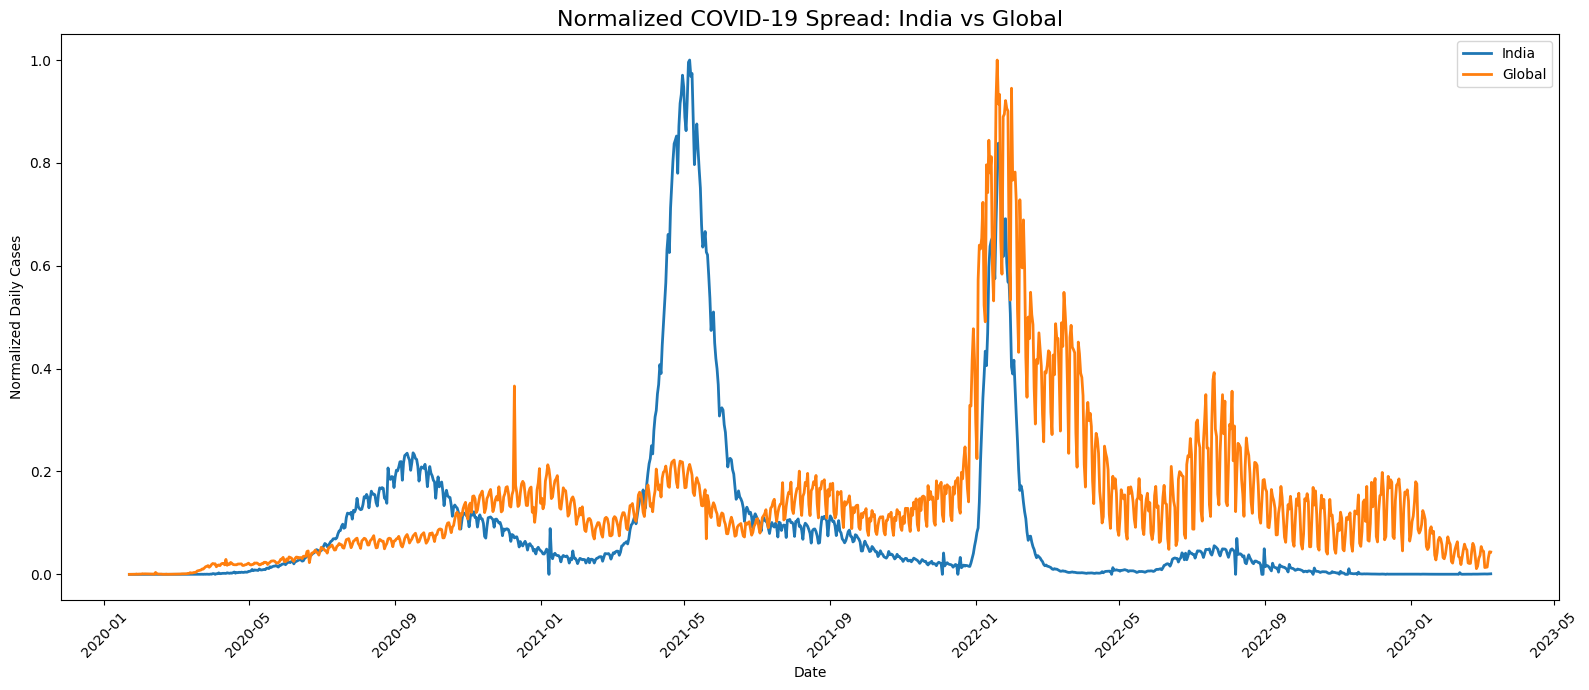

In [29]:
# India vs Global COVID-19 Spread Comparison

india_compare = india[['Date', 'New_Cases']].copy()

india_compare['India_Normalized'] = (
    india_compare['New_Cases'] /
    india_compare['New_Cases'].max()
)

global_compare = global_data[['Date', 'New_Cases']].copy()

global_compare['Global_Normalized'] = (
    global_compare['New_Cases'] /
    global_compare['New_Cases'].max()
)

# Plot
plt.figure(figsize=(16, 7))

plt.plot(
    india_compare['Date'],
    india_compare['India_Normalized'],
    label='India',
    linewidth=2
)

plt.plot(
    global_compare['Date'],
    global_compare['Global_Normalized'],
    label='Global',
    linewidth=2
)

plt.title(
    'Normalized COVID-19 Spread: India vs Global',
    fontsize=16
)

plt.xlabel('Date')
plt.ylabel('Normalized Daily Cases')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

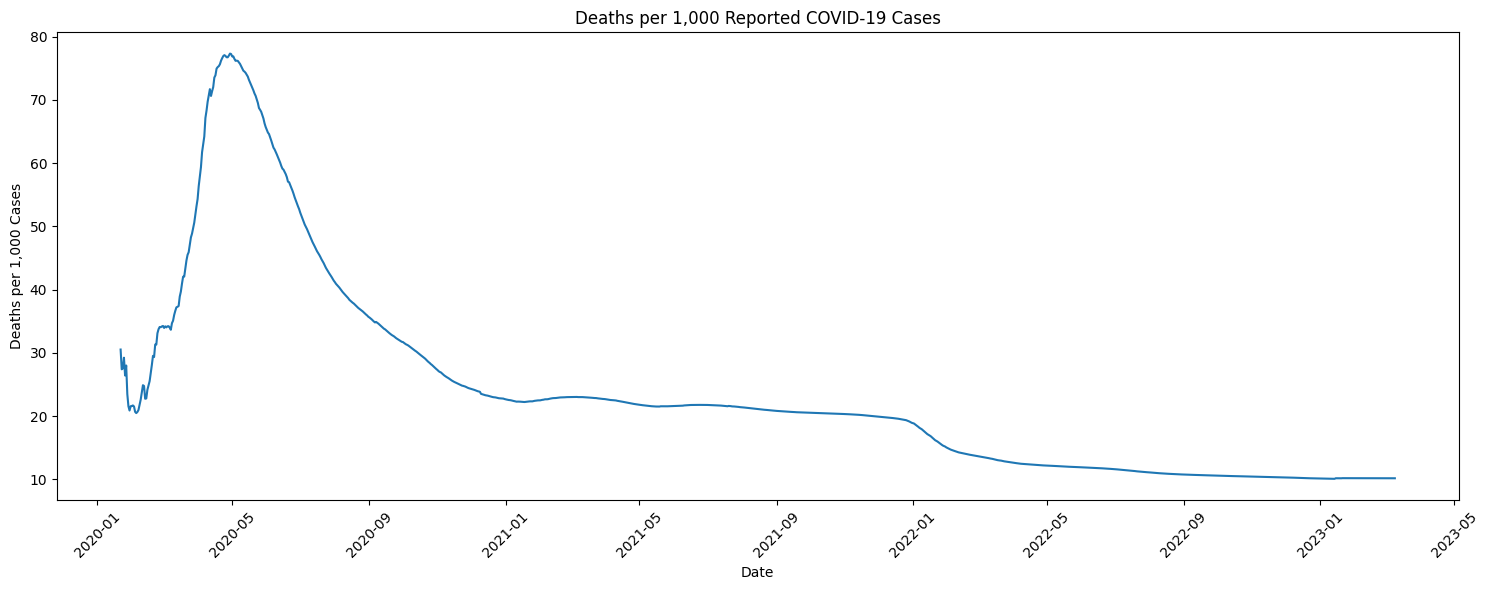

In [30]:
global_data['Deaths_per_1000_Cases'] = np.where(
    global_data['Confirmed'] > 0,
    (global_data['Deaths'] / global_data['Confirmed']) * 1000,
    np.nan
)

plt.figure(figsize=(15,6))

plt.plot(
    global_data['Date'],
    global_data['Deaths_per_1000_Cases']
)

plt.title('Deaths per 1,000 Reported COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('Deaths per 1,000 Cases')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
global_data['7_Day_Avg'] = (
    global_data['New_Cases']
    .rolling(7)
    .mean()
)

q1 = global_data['7_Day_Avg'].quantile(0.25)
q2 = global_data['7_Day_Avg'].quantile(0.50)
q3 = global_data['7_Day_Avg'].quantile(0.75)

def severity(x):
    if x <= q1:
        return 'Low'
    elif x <= q2:
        return 'Moderate'
    elif x <= q3:
        return 'High'
    else:
        return 'Very High'

global_data['Severity'] = (
    global_data['7_Day_Avg']
    .apply(severity)
)

global_data[['Date', '7_Day_Avg', 'Severity']].tail()

,Date,7_Day_Avg,Severity
1138,2023-03-05,140069.571429,Low
1139,2023-03-06,130214.571429,Low
1140,2023-03-07,127305.714286,Low
1141,2023-03-08,121424.571429,Low
1142,2023-03-09,119748.285714,Low


In [32]:
# Prepare India data for prediction

prediction_data = india[
    ['Date', 'New_Cases']
].copy()

prediction_data = prediction_data.reset_index(drop=True)

# Create previous 7-day values
for i in range(1, 8):
    prediction_data[f'Lag_{i}'] = (
        prediction_data['New_Cases'].shift(i)
    )

prediction_data = prediction_data.dropna()

prediction_data.head()

,Date,New_Cases,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7
7,2020-01-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2020-01-30,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2020-01-31,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
10,2020-02-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
11,2020-02-02,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [33]:
# Prepare training data

features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_4',
    'Lag_5',
    'Lag_6',
    'Lag_7'
]

X = prediction_data[features]
y = prediction_data['New_Cases']

# Train the model
model = LinearRegression()

model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


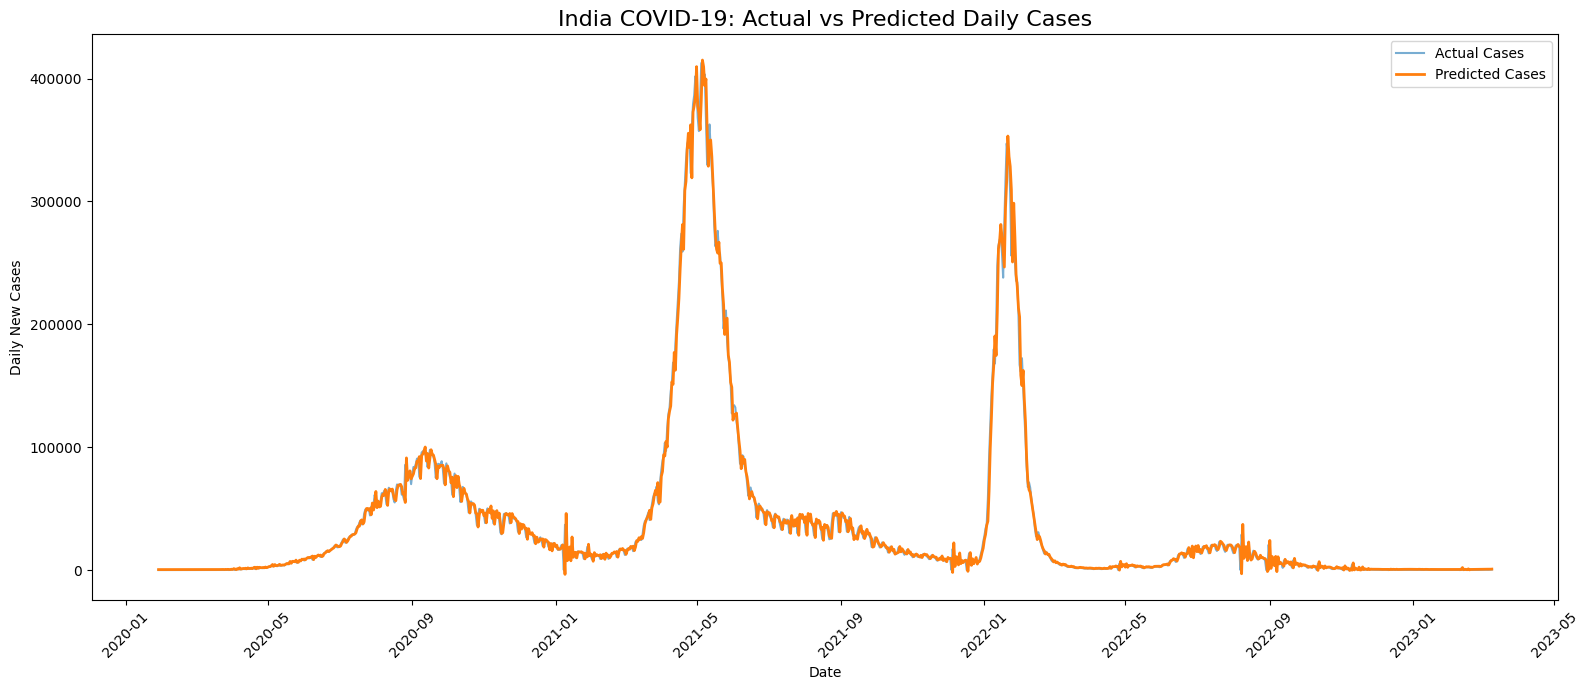

In [34]:
# Historical predictions

prediction_data['Predicted_Cases'] = model.predict(X)

plt.figure(figsize=(16, 7))

plt.plot(
    prediction_data['Date'],
    prediction_data['New_Cases'],
    label='Actual Cases',
    alpha=0.6
)

plt.plot(
    prediction_data['Date'],
    prediction_data['Predicted_Cases'],
    label='Predicted Cases',
    linewidth=2
)

plt.title(
    'India COVID-19: Actual vs Predicted Daily Cases',
    fontsize=16
)

plt.xlabel('Date')
plt.ylabel('Daily New Cases')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# Predict the next 7 days

last_7_cases = list(
    india['New_Cases'].tail(7)
)

future_predictions = []

for day in range(7):

    # Create a DataFrame with the SAME feature names used during training
    X_future = pd.DataFrame(
        [last_7_cases[-7:]],
        columns=features
    )

    # Predict next day
    predicted = model.predict(X_future)[0]

    # Cases cannot be negative
    predicted = max(0, predicted)

    future_predictions.append(predicted)

    # Add prediction for use in next day
    last_7_cases.append(predicted)

# Create future dates
last_date = india['Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7
)

forecast = pd.DataFrame({
    'Date': future_dates,
    'Predicted_New_Cases': future_predictions
})

forecast

,Date,Predicted_New_Cases
0,2023-03-10,701.693587
1,2023-03-11,638.256199
2,2023-03-12,696.474736
3,2023-03-13,591.172986
4,2023-03-14,712.476529
5,2023-03-15,729.872055
6,2023-03-16,768.600809


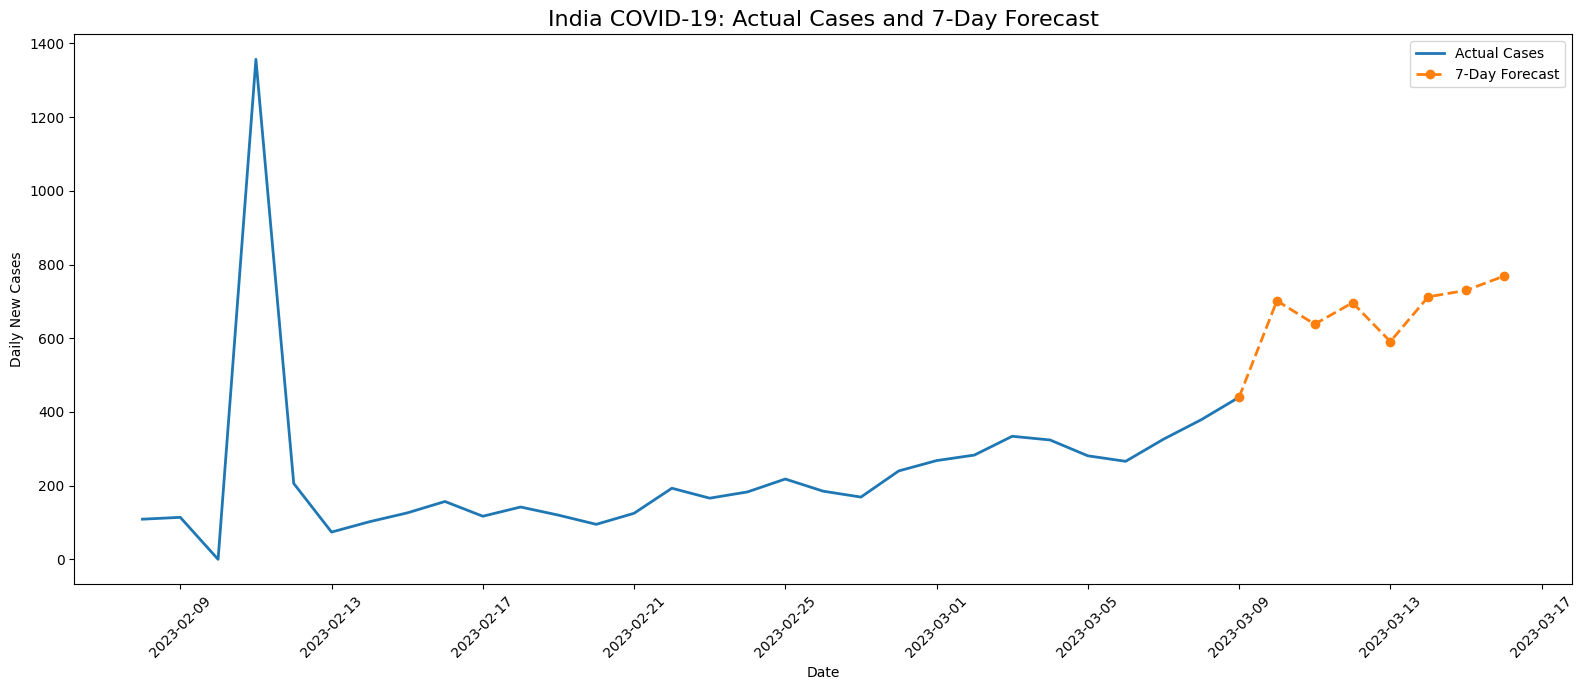

In [36]:
# Plot actual cases + 7-day forecast as one continuous graph

plt.figure(figsize=(16, 7))

# Show the last 30 actual days
recent_actual = india.tail(30).copy()

# Combine the last actual point with the forecast
forecast_plot = pd.concat([
    recent_actual[['Date', 'New_Cases']].rename(
        columns={'New_Cases': 'Cases'}
    ),
    forecast[['Date', 'Predicted_New_Cases']].rename(
        columns={'Predicted_New_Cases': 'Cases'}
    )
])

# Actual cases
plt.plot(
    recent_actual['Date'],
    recent_actual['New_Cases'],
    label='Actual Cases',
    linewidth=2
)

# Forecast starting from the LAST actual point
forecast_dates = pd.concat([
    recent_actual[['Date']].tail(1),
    forecast[['Date']]
])

forecast_values = pd.concat([
    recent_actual[['New_Cases']].tail(1).rename(
        columns={'New_Cases': 'Predicted_New_Cases'}
    ),
    forecast[['Predicted_New_Cases']]
])

plt.plot(
    forecast_dates['Date'],
    forecast_values['Predicted_New_Cases'],
    marker='o',
    linestyle='--',
    label='7-Day Forecast',
    linewidth=2
)

plt.title(
    'India COVID-19: Actual Cases and 7-Day Forecast',
    fontsize=16
)

plt.xlabel('Date')
plt.ylabel('Daily New Cases')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()